In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits

# Barplot

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


<Axes: >

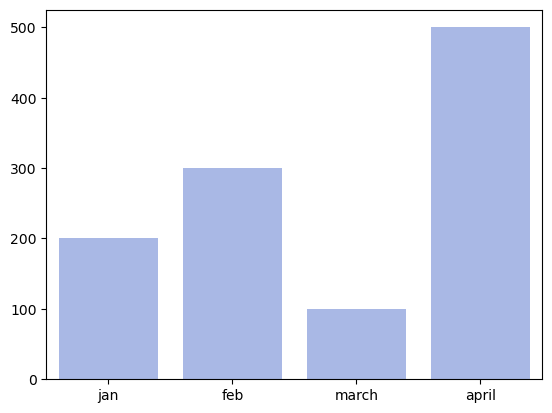

In [2]:
data=[200,300,100,500]
mon=['jan','feb','march','april']
sns.barplot(y=data,x=mon,color="royalblue",alpha=0.5)

<BarContainer object of 4 artists>

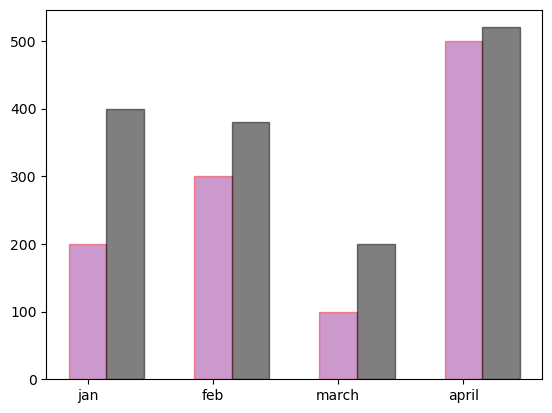

In [40]:
#multi bar
data2=[400,380,200,520]
plt.bar(mon,height=data,width=0.3,color="purple",alpha=0.4,edgecolor="red")
plt.bar(np.arange(len(data2))+0.3,data2,width=0.3,color="black",alpha=0.5,edgecolor="black")

<BarContainer object of 4 artists>

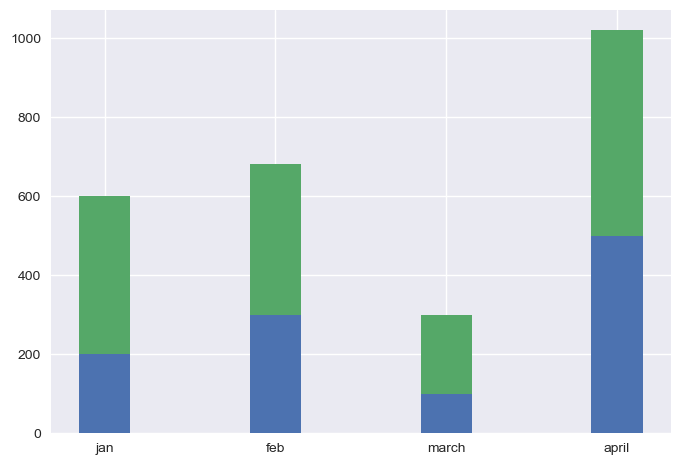

In [47]:
#Stacked bar
plt.style.use("seaborn-v0_8")
plt.bar(mon,data,width=0.3)
plt.bar(mon,data2,width=0.3,bottom=data)

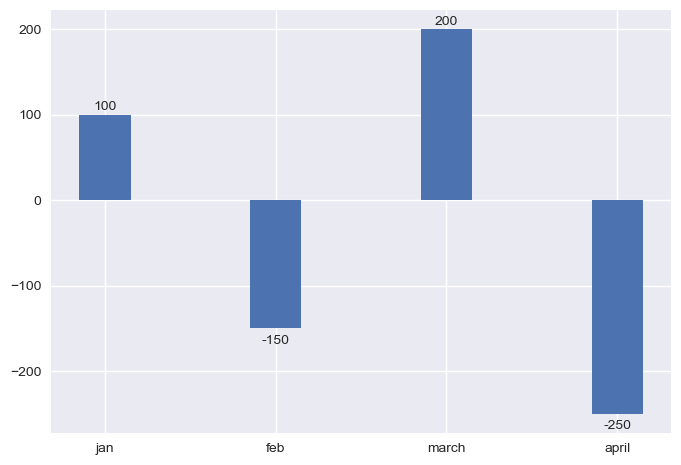

In [128]:
plt.style.use("seaborn-v0_8")
plt.grid(True)
data3=[100,-150,200,-250]
plt.bar(mon,data3,width=0.3)
for i in range(len(data3)):
    if data3[i]<0:
        plt.text(i,data3[i]-14,data3[i], ha='center', va='center')
    elif data3[i]>0:
        plt.text(i,data3[i]+9,data3[i], ha='center', va='center')

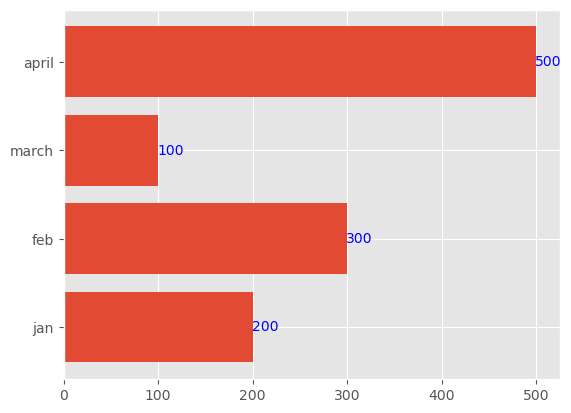

In [223]:
#horizontal bar
plt.barh(mon,data)
for i in range(len(data)):
    plt.text(data[i]+13,i,data[i], ha='center', va='center',color="blue")


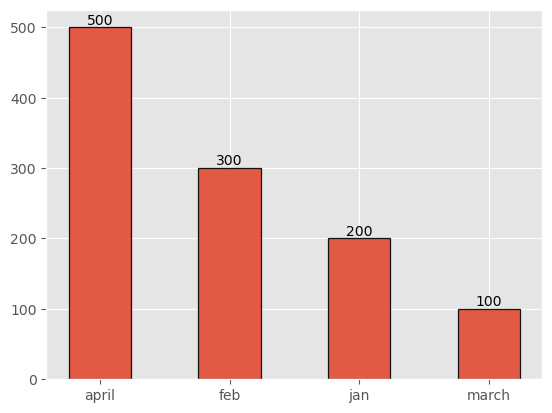

In [222]:
#Ordered Barchart
df=pd.DataFrame({"Month":mon,"Sales":data})
df.sort_values(by="Sales",inplace=True)
plt.style.use("ggplot")
plt.bar(df['Month'][::-1],df['Sales'][::-1],width=0.48,alpha=0.9,edgecolor="black",linewidth=0.9)
for i, sales in enumerate(df['Sales'][::-1]):
    plt.text(i, sales, sales, ha='center', va='bottom',color="black")

In [8]:
df=pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/gapminder_with_codes.csv")
df

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


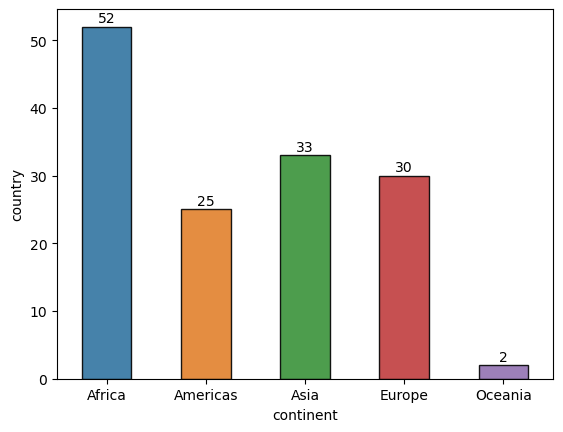

In [29]:
df=df[df['year']==2007]
counts=pd.pivot_table(df,index="continent",values="country",aggfunc="count")
counts
sns.barplot(x=counts.index,y=counts['country'],width=0.5,alpha=0.9,edgecolor="black")

for i,j in enumerate(counts['country']):
    plt.text(i,j+1.2,j,ha='center',va='center')

In [46]:
df['Pop_cat']=np.where(df['pop'] < 5000000, "Pop LT 5 MIL",
         np.where((df['pop'] >= 5000000) & (df['pop'] < 10000000), "Pop LT 10 MIL", "Pop GT 10 MIL"))

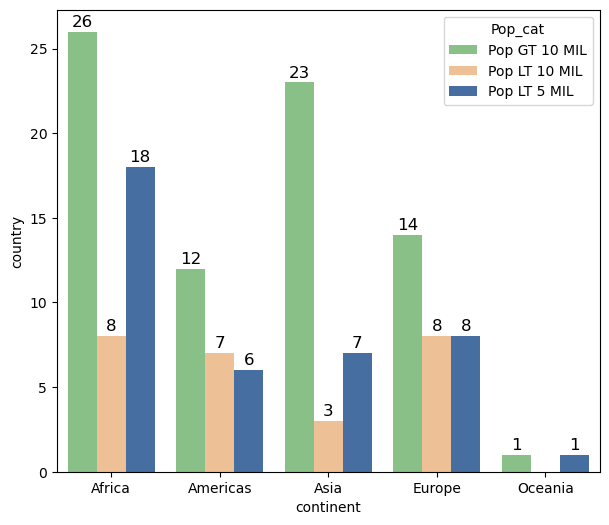

In [93]:
data=pd.pivot_table(df,index=['continent',"Pop_cat"],values="country",aggfunc="count").reset_index()


fig,ax=plt.subplots(figsize=(7,6))

cmap = plt.get_cmap("Accent")
colors = cmap(np.linspace(0.1, 3, len(data)))

ax=sns.barplot(x=data['continent'],y=data['country'],hue=data['Pop_cat'],palette=colors)

for bar in ax.patches:
    ax.annotate(format(bar.get_height(),'.0f'),
               (bar.get_x()+bar.get_width()/2,bar.get_height()),ha="center",va="center",size=12,xytext=(0,7),textcoords='offset points')

In [76]:
len(colors)

14

# Area Chart

(0.0, 4000.0)

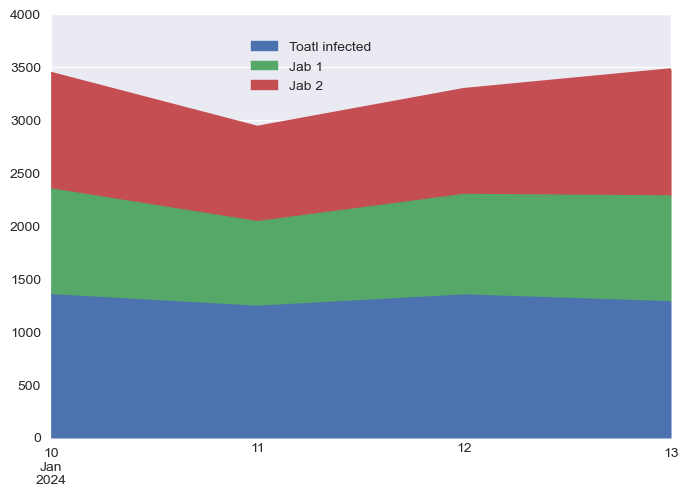

In [43]:
df=pd.DataFrame({
    "Toatl infected":[1345,1235,1342,1278],
    "Jab 1":[1000,800,950,1000],
    "Jab 2":[1100,900,1000,1200]
},index=pd.date_range(start="2024/01/10",end="2024/01/13",freq='D'))
plt.style.use("seaborn-v0_8")
ax=df.plot.area(stacked=True)
plt.legend(loc="center",bbox_to_anchor=(0.17, 0.7, 0.5, 0.35))
plt.ylim(0,4000)

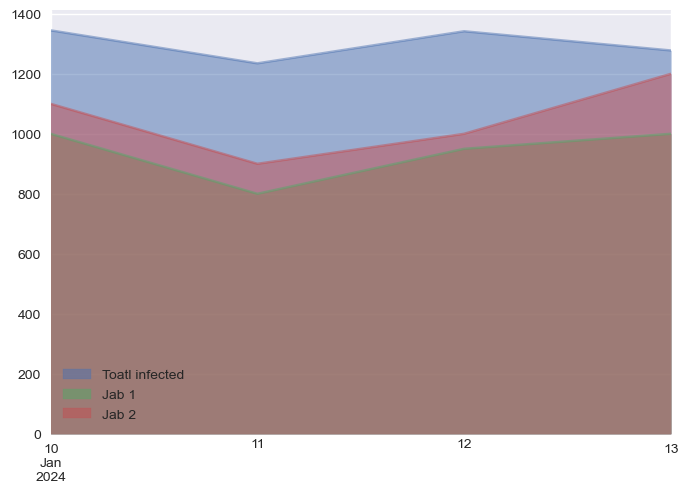

In [44]:
df=pd.DataFrame({
    "Toatl infected":[1345,1235,1342,1278],
    "Jab 1":[1000,800,950,1000],
    "Jab 2":[1100,900,1000,1200]
},index=pd.date_range(start="2024/01/10",end="2024/01/13",freq='D'))
plt.style.use("seaborn-v0_8")
ax=df.plot.area(stacked=False)
plt.legend()

# Pie

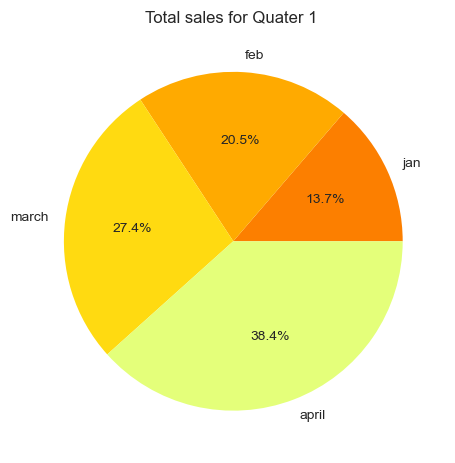

In [34]:
x=[10000,15000,20000,28000]
lab=["jan",'feb','march','april']
cmap=plt.get_cmap("Wistia_r")
colors = cmap(np.linspace(0, 1, len(x)))
plt.pie(x,labels=lab,autopct='%.1f%%',colors=colors)
plt.title("Total sales for Quater 1 ")
plt.show()

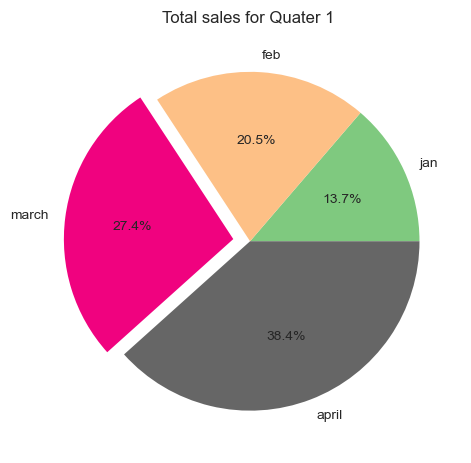

In [51]:
x=[10000,15000,20000,28000]
lab=["jan",'feb','march','april']
cmap=plt.get_cmap("Accent")
colors = cmap(np.linspace(0, 1, len(x)))
explode = [0,0,0.1,0]
plt.pie(x,labels=lab,autopct='%.1f%%',colors=colors,explode=explode)
plt.title("Total sales for Quater 1 ")
plt.show()

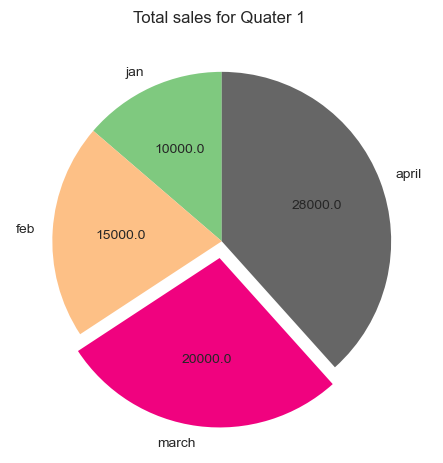

In [62]:
#starangle and abosolte value
x=[10000,15000,20000,28000]
lab=["jan",'feb','march','april']

s=sum(x)
def abs(val):
    a=np.round(s*val/100,0)
    return a

cmap=plt.get_cmap("Accent")
colors = cmap(np.linspace(0, 1, len(x)))
explode = [0,0,0.1,0]
plt.pie(x,labels=lab,autopct=abs,colors=colors,explode=explode,startangle=90)
plt.title("Total sales for Quater 1 ")
plt.show()

# Bubble Charts 

In [3]:
#bubble charts are scatter plots with dots or bubbles parameterised based on variable
df=pd.read_excel(r"C:\Users\jainn\OneDrive\Documents\Sem 2\r prog\Gapminder_EDA\gapminder_full.xlsx")
df=df[df['year']==2007]
df.reset_index(inplace=True)

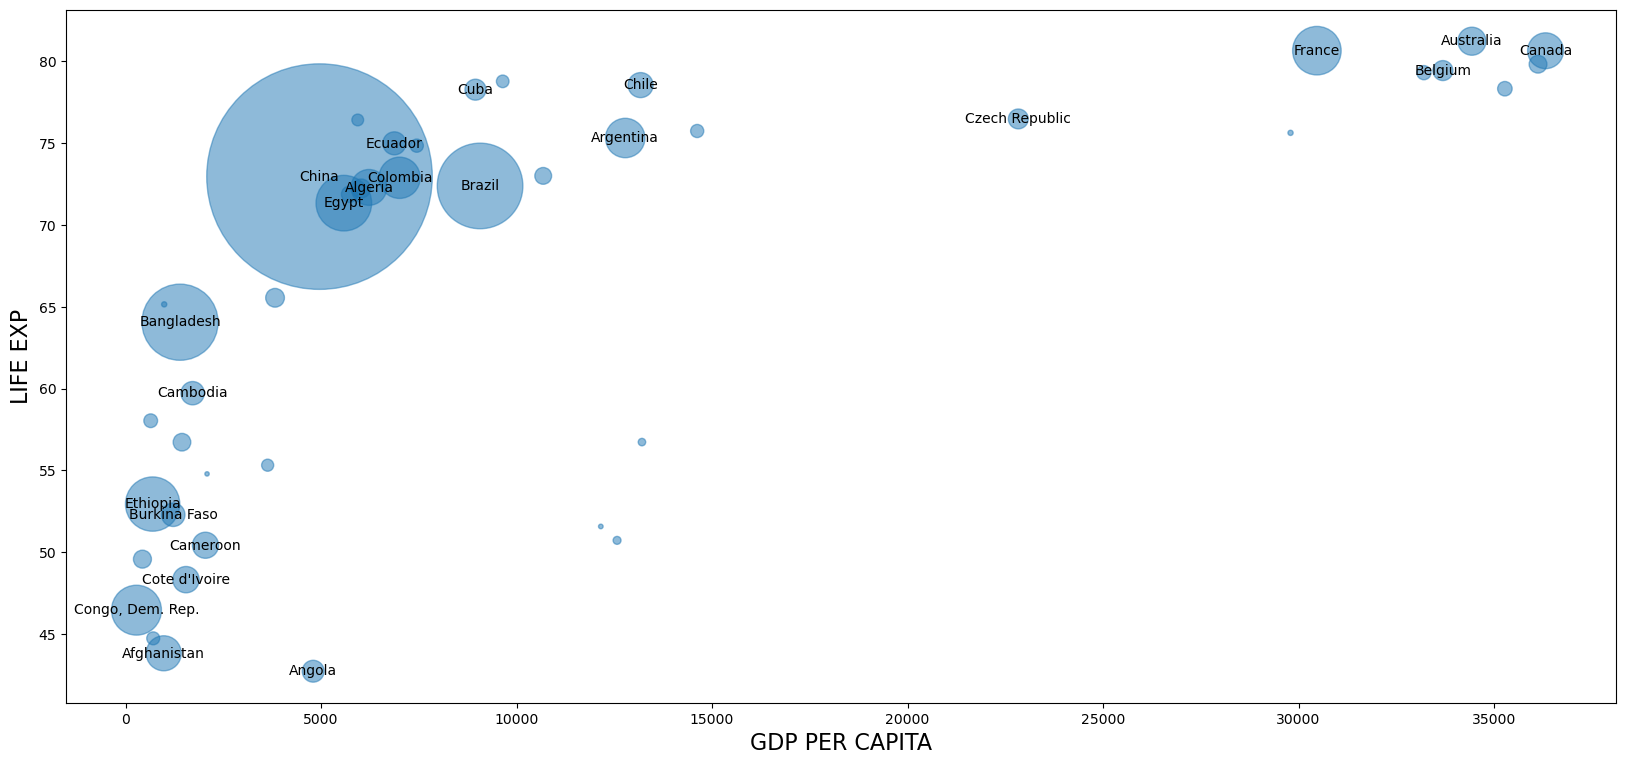

In [4]:
fig,ax=plt.subplots(figsize=(20,9))
ax.scatter(df['gdp_cap'],df['life exp'],s=df['population']/50000,alpha=0.5)
plt.xlabel("GDP PER CAPITA",size=16)
plt.ylabel("LIFE EXP",size=16)
for i,j in enumerate(df['population']):
    if j/50000>200:
        plt.annotate(df.loc[i,'country'],xy=(df.loc[i,'gdp_cap'],df.loc[i,'life exp']),ha="center",va="center")

# Regression Lines

In [35]:
import statsmodels.api as sm
X=np.random.rand(100)
Y=X+np.random.rand(100)*0.1

result=sm.OLS(Y,sm.add_constant(X)).fit()
print(result.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     9378.
Date:                Thu, 11 Apr 2024   Prob (F-statistic):           4.20e-99
Time:                        23:09:40   Log-Likelihood:                 209.42
No. Observations:                 100   AIC:                            -414.8
Df Residuals:                      98   BIC:                            -409.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0518      0.006      8.824      0.0

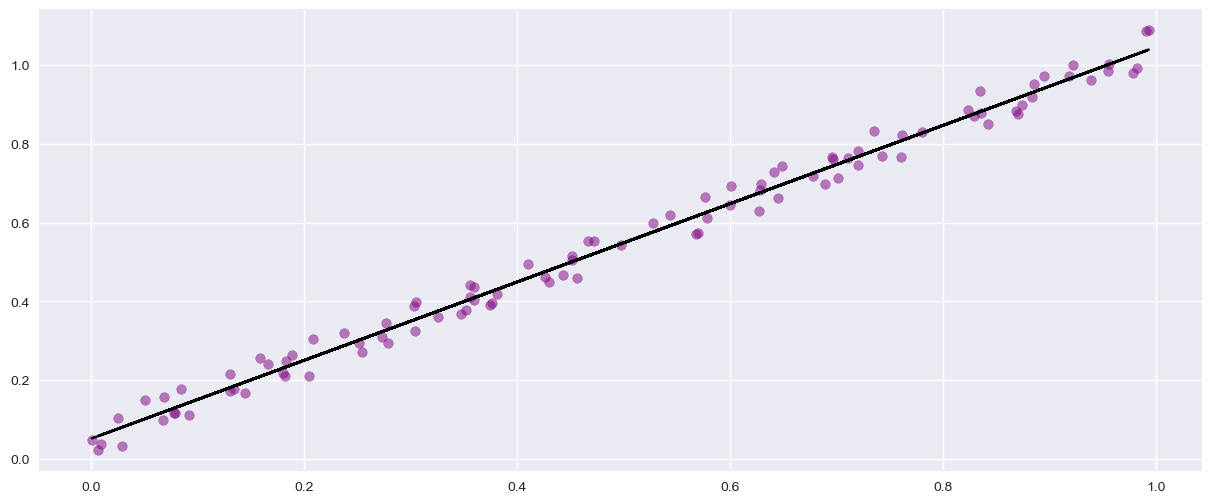

In [36]:
plt.style.use("seaborn-v0_8")
plt.figure(figsize=(15,6))
plt.scatter(X,Y,color="purple",alpha=0.5)
xp=np.linspace(0,1,100)
plt.plot(X,X*result.params[1]+result.params[0],color="black")

In [43]:
df

,level_0,index,country,year,population,life exp,gdp_cap
0,11,1012,Afghanistan,2007,3.188992e+07,43.828,974.580338
1,23,1024,Albania,2007,3.600523e+06,76.423,5937.029526
2,35,1036,Algeria,2007,3.333322e+07,72.301,6223.367465
3,47,1048,Angola,2007,1.242048e+07,42.731,4797.231267
4,59,1060,Argentina,2007,4.030193e+07,75.320,12779.379640
5,71,1072,Australia,2007,2.043418e+07,81.235,34435.367440
6,83,1084,Austria,2007,8.199783e+06,79.829,36126.492700
7,95,1096,Bahrain,2007,7.085730e+05,75.635,29796.048340
8,107,1108,Bangladesh,2007,1.504483e+08,64.062,1391.253792
9,119,1120,Belgium,2007,1.039223e+07,79.441,33692.605080


# Slope plot

In [3]:
sns.set_theme(style="darkgrid")
df=sns.load_dataset("tips")

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='time', ylabel='total_bill'>

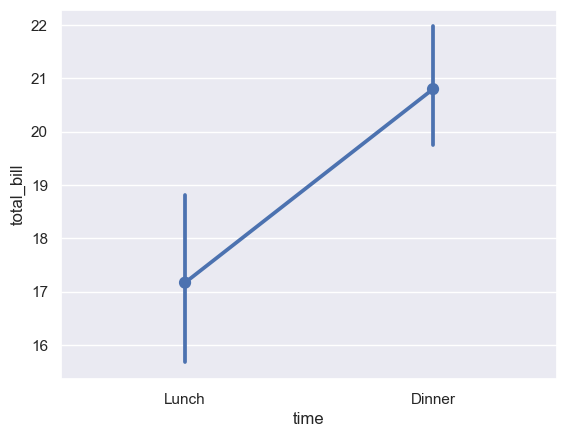

In [11]:
# plot the central tendencies and spread of lunch and dinner expenses by total popluation

sns.pointplot(data=df,x="time",y="total_bill",errorbar=('ci', 90)) #confindence interval

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='time', ylabel='total_bill'>

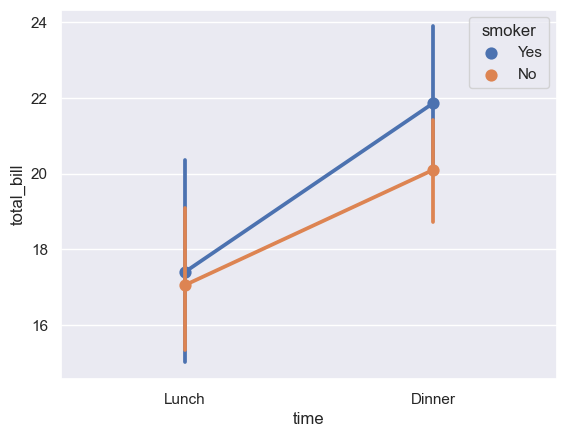

In [13]:
#compare between smoker and non smoker
sns.pointplot(data=df,x="time",y="total_bill",errorbar=('ci', 90),hue="smoker") 

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='time', ylabel='total_bill'>

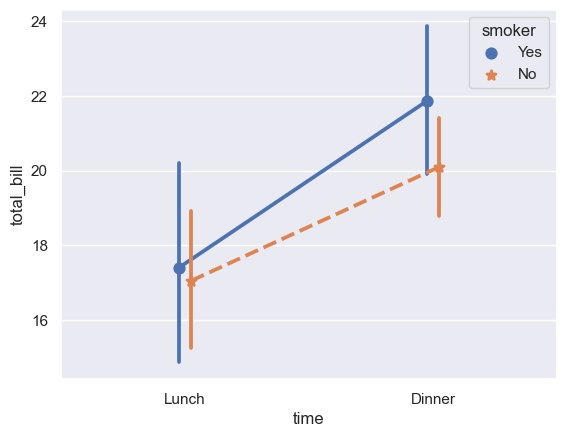

In [16]:
sns.pointplot(data=df,x="time",y="total_bill",errorbar=('ci', 90),hue="smoker",dodge=True,markers=['o','*'],linestyles=['-','--']) 

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='time', ylabel='total_bill'>

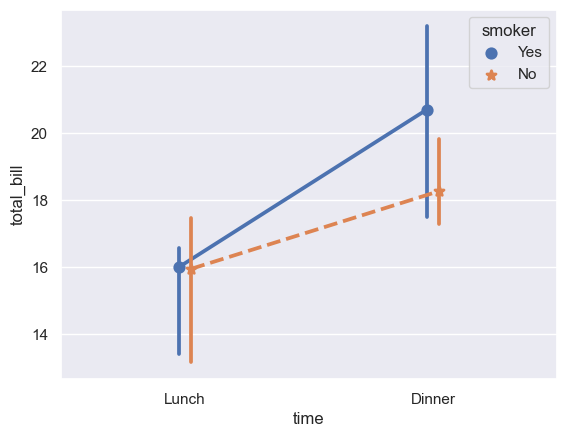

In [18]:
sns.pointplot(data=df,x="time",y="total_bill",errorbar=('ci', 90),hue="smoker",dodge=True,markers=['o','*'],linestyles=['-','--'],estimator="median") 

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='time', ylabel='total_bill'>

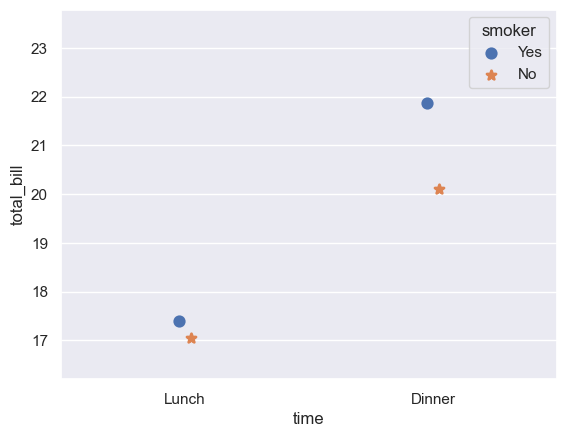

In [31]:
sns.pointplot(data=df,x="time",y="total_bill",
              errorbar=('ci', 90),
              hue="smoker",dodge=True,
              markers=['o','*'],linestyles=['-','--'],
              estimator="mean",
              n_boot=1,join=False) 

# Dumble plot

In [2]:
df=pd.read_excel(r"C:\Users\jainn\OneDrive\Documents\Sem 2\r prog\Gapminder_EDA\gapminder_full.xlsx")


In [3]:
data=pd.pivot_table(df[df['year']==2002],index="country",values="gdp_cap",aggfunc="sum").merge(
    pd.pivot_table(df[df['year']==2007],index="country",values="gdp_cap",aggfunc="sum"),on="country"
).assign(Diff = lambda x :x['gdp_cap_y']-x['gdp_cap_x']).sort_values(by="Diff",ascending=False).head(10)

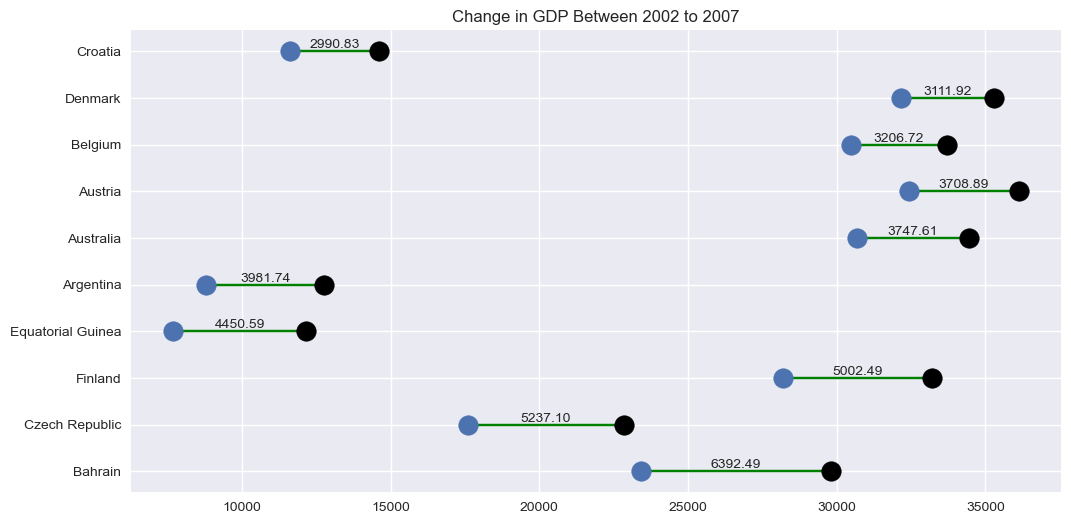

In [4]:
fig=plt.figure(figsize=(12,6))
plt.style.use("seaborn-v0_8")
plt.scatter(data['gdp_cap_x'],data.index,s=200,zorder=3)
plt.scatter(data['gdp_cap_y'],data.index,s=200,zorder=3,color="black")
plt.hlines(y=data.index,xmin=data['gdp_cap_x'],xmax=data['gdp_cap_y'],color="green")
plt.title("Change in GDP Between 2002 to 2007")
for i, (x, y, diff) in enumerate(zip(data['gdp_cap_x'], data['gdp_cap_y'], data['Diff'])):
    plt.text((x + y) / 2, i, f"{diff:.2f}", ha='center', va='bottom')

# heatmaps

In [5]:
df=sns.load_dataset("mpg")
df.dropna(inplace=True)
df=df.drop(columns={'name','origin'})

<Axes: >

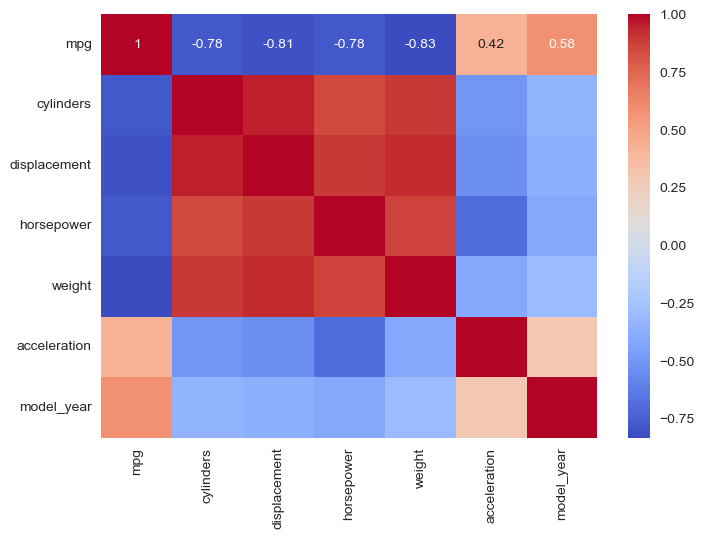

In [6]:
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)

# Pairplot

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

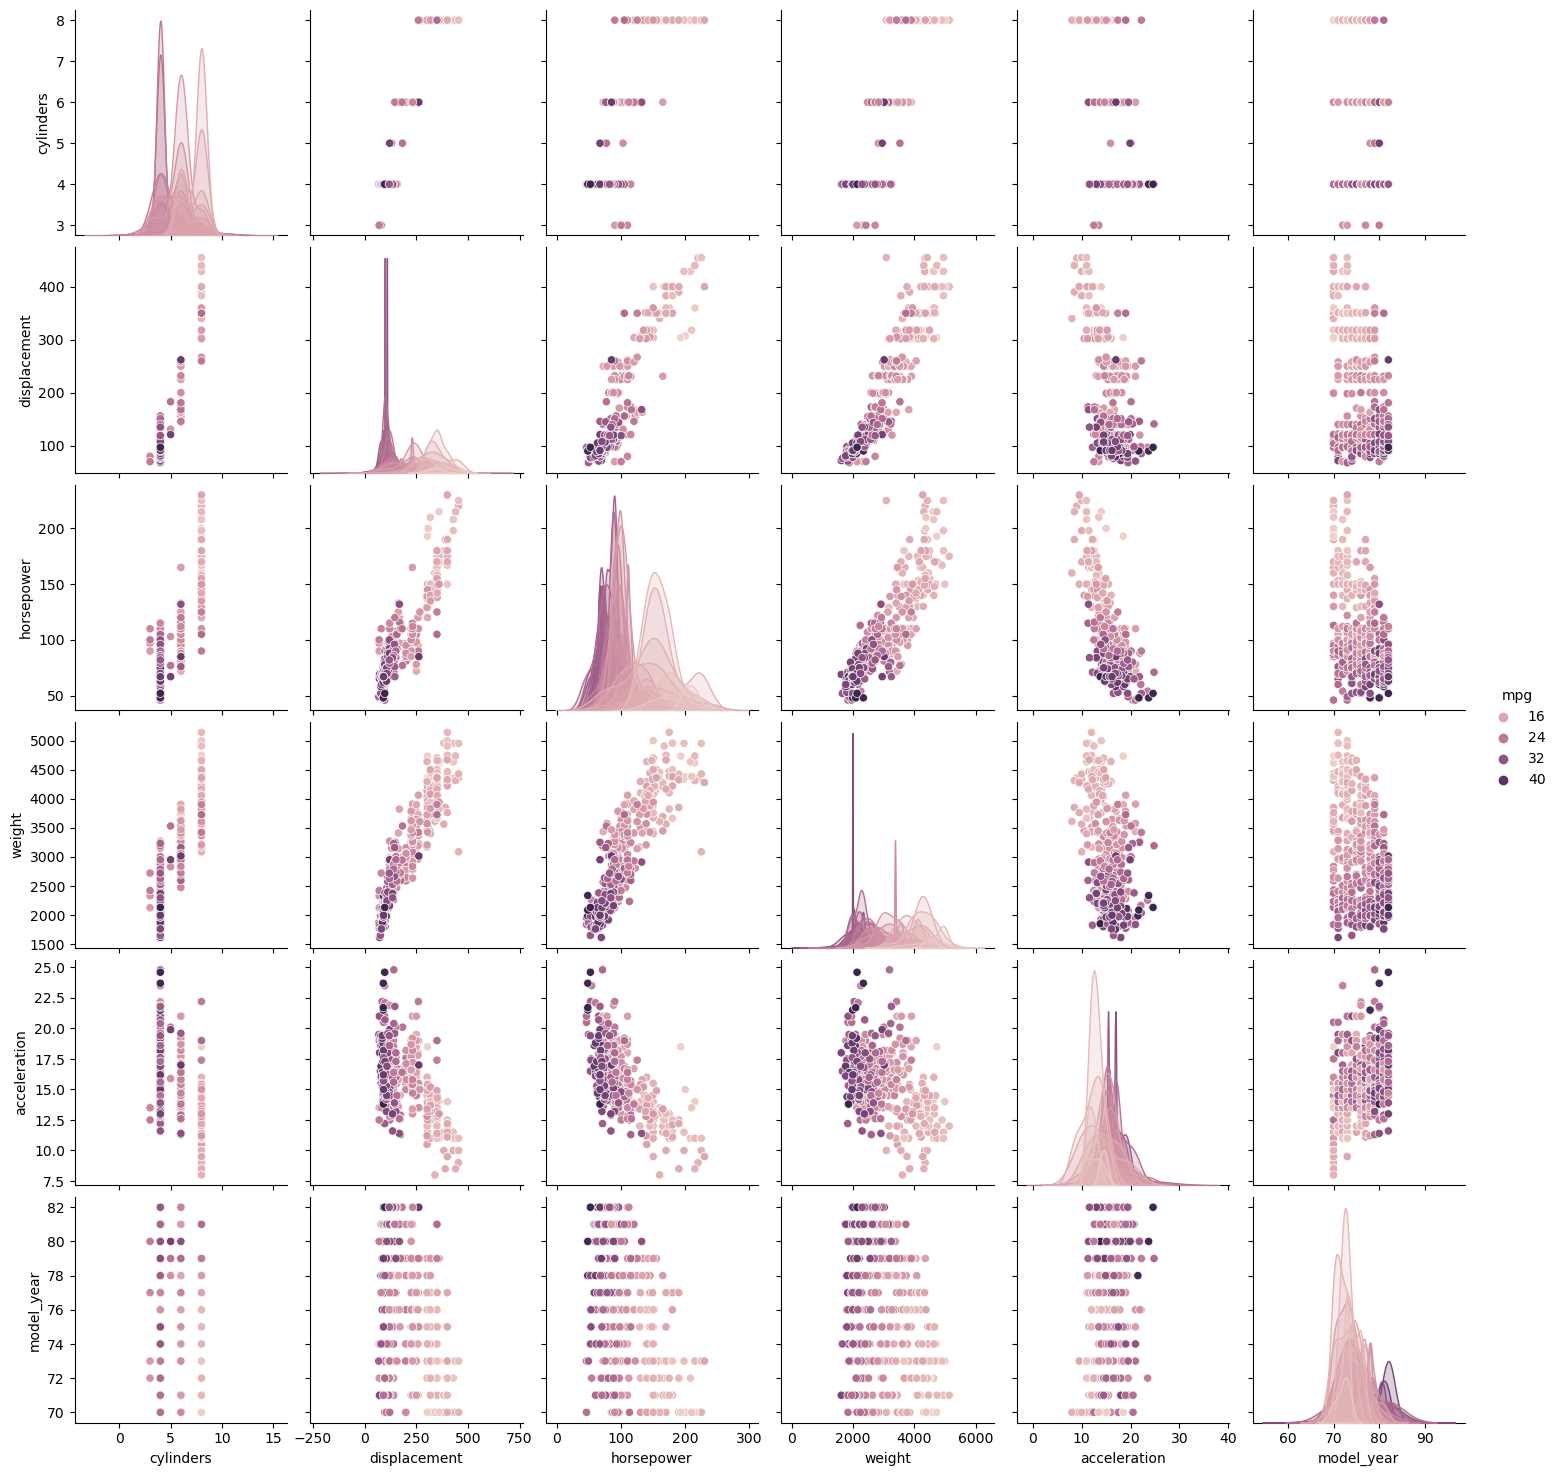

In [104]:
sns.pairplot(df,hue='mpg',kind='scatter')

# Seasonal plots (lineplot)

In [118]:
df=sns.load_dataset("flights")
from datetime import datetime
df['report-date'] = df.apply(lambda x: datetime.strptime(f"{x['year']}-{x['month']}", '%Y-%b').strftime('%Y-%m-%d'), axis=1)

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Airline passengers over time')

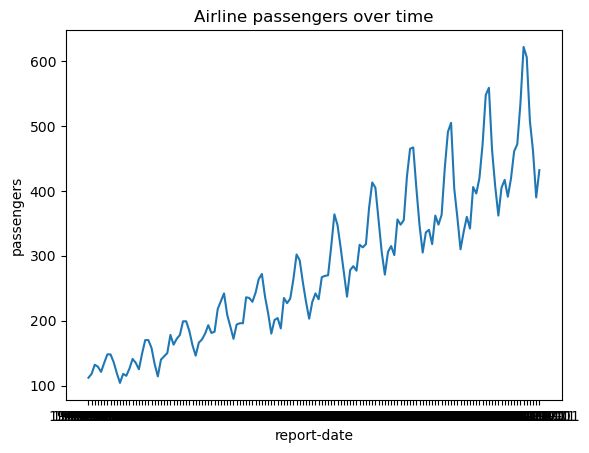

In [121]:
sns.lineplot(df,
            x='report-date',
            y='passengers').set_title("Airline passengers over time")

C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jainn\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


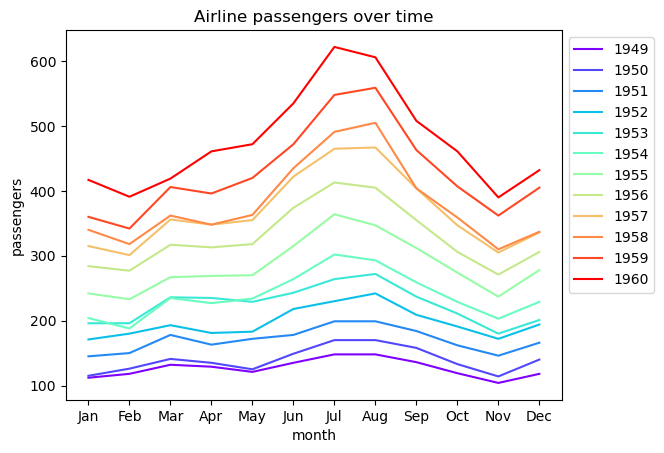

In [132]:
sns.lineplot(df,
            x='month',
            y='passengers',
            hue='year',
            legend='full',palette="rainbow").set_title("Airline passengers over time")
plt.legend(bbox_to_anchor=(1.2,1))

# Yearplot

In [9]:
import calmap

(<Figure size 800x400 with 3 Axes>,
 array([<Axes: ylabel='2024'>, <Axes: ylabel='2025'>,
        <Axes: ylabel='2026'>], dtype=object))

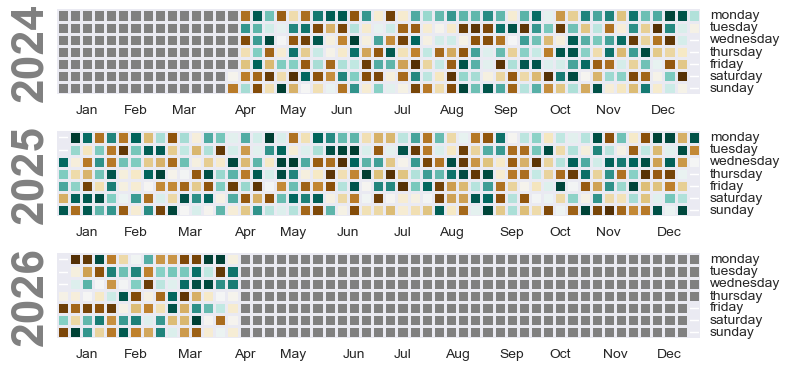

In [59]:
df=pd.DataFrame({"date":pd.date_range('13/4/2024',periods=730,freq='D'),
                'sales':np.random.rand(730)*20}).set_index("date")
calmap.calendarplot(df,daylabels=["monday","tuesday","wednesday","thursday","friday","saturday","sunday"],fillcolor="grey",fig_kws=dict(figsize=(8,4)),
                                                                                                                                       cmap="BrBG_r")

# Radar plot

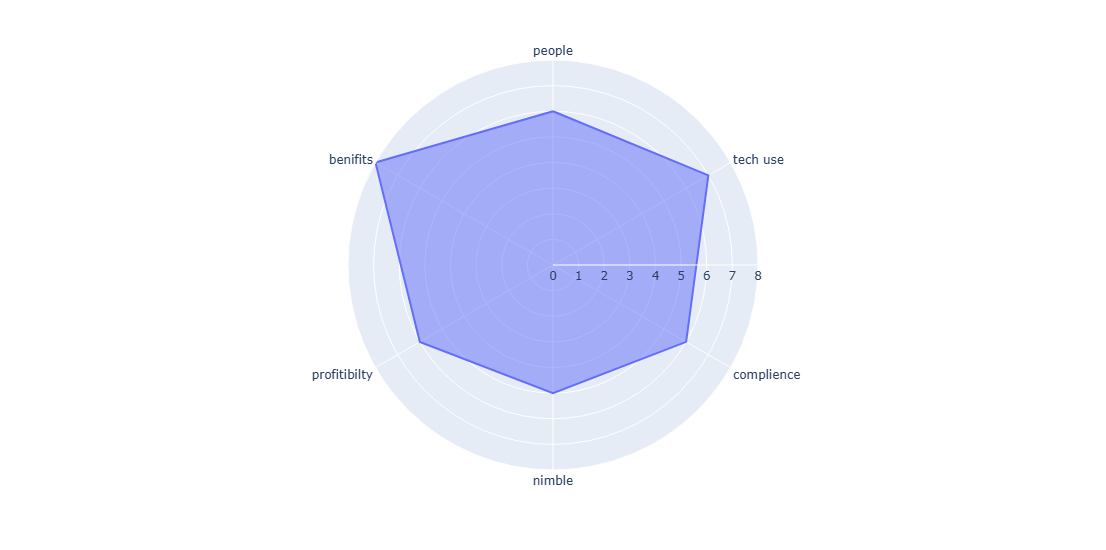

In [46]:
data=pd.DataFrame({"theta":['people','tech use','complience','nimble','profitibilty','benifits'],
                  "r1":[6,7,6,5,6,8],
                  "r2":[8,5,6,7,8,7]})
# data['the']=data['theta'].map({j:i for i,j in enumerate(data['theta'])})

import plotly.express as px
fig=px.line_polar(data,r="r1",theta="theta",line_close=True)
fig.update_traces(fill="toself")
fig.update_layout(
    width=800,  
    height=550,  
)
fig.show()

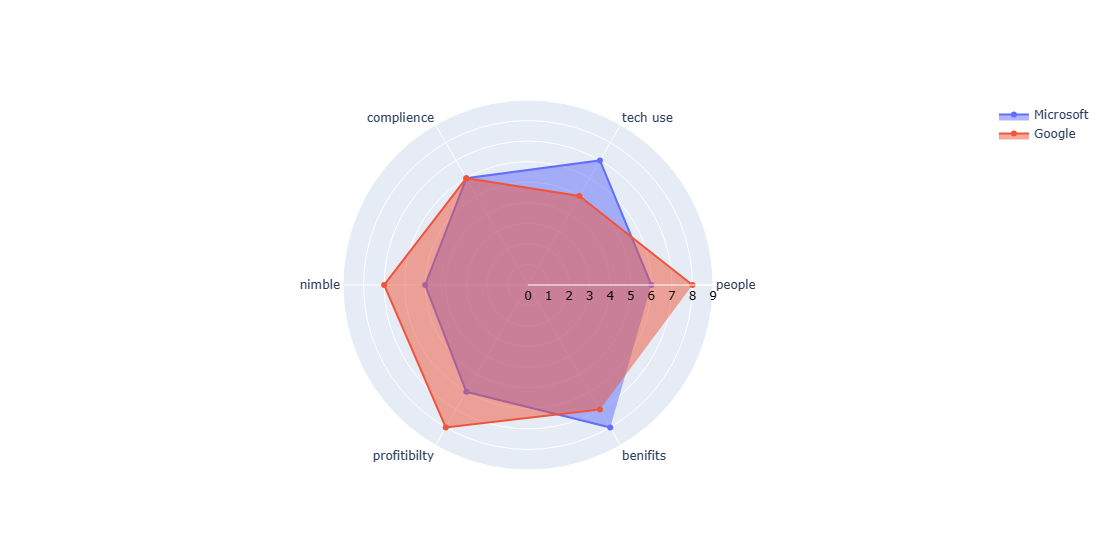

In [54]:
import plotly.graph_objects as go

fig=go.Figure()

fig.update_layout(
    width=800,  
    height=550,  
    polar=dict(radialaxis=dict(visible=True,range=[0,9],color="black")),showlegend=True
)

fig.add_trace(go.Scatterpolar(r=data['r1'],theta=data['theta'],fill='toself',name="Microsoft"))
fig.add_trace(go.Scatterpolar(r=data['r2'],theta=data['theta'],fill='toself',name="Google"))

In [45]:
data

,theta,r1,r2
0,people,6,8
1,tech use,7,5
2,complience,6,6
3,nimble,5,7
4,profitibilty,6,8
5,benifits,8,4
